# Cristiano Ronaldo - Shot Prediction Analysis

---

## 1. Problem Statement

### 1.1 Business Context

In professional football, understanding the factors that influence whether a shot results in a goal is critical for teams, analysts, and coaching staff. By analyzing historical shot data, we can build predictive models that estimate the probability of a shot being converted into a goal. These insights can support tactical decision-making, player performance evaluation, and game strategy optimization.

### 1.2 Objective

The objective of this project is to build a binary classification model that predicts whether a given shot attempt by Cristiano Ronaldo will result in a goal or not. The target variable is **is_goal**, where:
- 1 indicates the shot was a goal
- 0 indicates the shot was not a goal

The dataset contains records where the target variable is missing (null). These records form the test set, and our trained model will generate predictions for them.

### 1.3 Approach

The project follows a structured machine learning pipeline:
1. Data Loading and Initial Exploration
2. Data Preprocessing (handling missing values, encoding, feature engineering)
3. Exploratory Data Analysis (EDA)
4. Train-Test Split based on target availability
5. Model Building using multiple classification algorithms
6. Model Evaluation and Comparison
7. Generating predictions on the test set

### 1.4 Dataset

The dataset **yds_data.csv** contains approximately 30,697 records of shot attempts with features including shot location, distance, power, game context, and more.

## 2. Importing Libraries

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import random
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier, ExtraTreesClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation metrics
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, roc_auc_score, roc_curve,
                              f1_score, precision_score, recall_score)

# Set random seed for reproducibility
np.random.seed(42)
random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading and Initial Inspection

In [5]:
# Reading the dataset
data = pd.read_csv("yds_data.csv")

# Convert all string-dtype columns to plain object dtype for consistent handling
for col in data.columns:
    if pd.api.types.is_string_dtype(data[col]):
        data[col] = data[col].astype('object')

print("Dataset loaded successfully.")
print("Shape of the dataset:", data.shape)

Dataset loaded successfully.
Shape of the dataset: (30697, 28)


In [6]:
# First few rows of the dataset
data.head()

,Unnamed: 0,match_event_id,location_x,location_y,remaining_min,power_of_shot,knockout_match,game_season,remaining_sec,distance_of_shot,...,lat/lng,type_of_shot,type_of_combined_shot,match_id,team_id,remaining_min.1,power_of_shot.1,knockout_match.1,remaining_sec.1,distance_of_shot.1
0,0,10.0,167.0,72.0,10.0,1.0,0.0,2000-01,27.0,38.0,...,"45.539131, -122.651648",shot - 30,NaN,20000012,1610612747,10.00,1.0,50.608,54.2000,38.0
1,1,12.0,-157.0,0.0,10.0,1.0,0.0,2000-01,22.0,35.0,...,"45.539131, -122.651648",shot - 45,NaN,20000012,1610612747,10.00,1.0,28.800,22.0000,35.0
2,2,35.0,-101.0,135.0,7.0,1.0,0.0,2000-01,45.0,36.0,...,"45.539131, -122.651648",shot - 25,NaN,20000012,1610612747,92.64,1.0,0.000,63.7216,54.4
3,3,43.0,138.0,175.0,6.0,1.0,0.0,2000-01,52.0,42.0,...,"45.539131, -122.651648",NaN,shot - 3,20000012,1610612747,NaN,1.0,122.608,52.0000,42.0
4,4,155.0,0.0,0.0,NaN,2.0,0.0,2000-01,19.0,20.0,...,"45.539131, -122.651648",NaN,shot - 1,20000012,1610612747,42.64,2.0,0.000,19.0000,20.0


In [7]:
# Last few rows of the dataset
data.tail()

,Unnamed: 0,match_event_id,location_x,location_y,remaining_min,power_of_shot,knockout_match,game_season,remaining_sec,distance_of_shot,...,lat/lng,type_of_shot,type_of_combined_shot,match_id,team_id,remaining_min.1,power_of_shot.1,knockout_match.1,remaining_sec.1,distance_of_shot.1
30692,30692,397.0,1.0,48.0,6.0,4.0,1.0,1999-00,5.0,24.0,...,"42.982923, -71.446094",shot - 1,NaN,49900088,1610612747,17.2,4.00,1.0,5.0,24.0
30693,30693,398.0,0.0,0.0,6.0,4.0,1.0,1999-00,5.0,20.0,...,"42.982923, -71.446094",shot - 49,NaN,49900088,1610612747,6.0,64.36,1.0,5.0,20.0
30694,30694,426.0,-134.0,166.0,3.0,4.0,1.0,1999-00,28.0,41.0,...,NaN,NaN,shot - 3,49900088,1610612747,3.0,4.00,1.0,28.0,41.0
30695,30695,448.0,31.0,267.0,2.0,4.0,1.0,1999-00,10.0,46.0,...,"42.982923, -71.446094",shot - 26,NaN,49900088,1610612747,2.0,112.36,1.0,10.0,46.0
30696,30696,471.0,1.0,NaN,0.0,4.0,1.0,1999-00,39.0,27.0,...,"42.982923, -71.446094",shot - 45,NaN,49900088,1610612747,0.0,4.00,1.0,39.0,27.0


In [8]:
# Column names
print("Columns in the dataset:")
print(data.columns.tolist())

Columns in the dataset:
['Unnamed: 0', 'match_event_id', 'location_x', 'location_y', 'remaining_min', 'power_of_shot', 'knockout_match', 'game_season', 'remaining_sec', 'distance_of_shot', 'is_goal', 'area_of_shot', 'shot_basics', 'range_of_shot', 'team_name', 'date_of_game', 'home/away', 'shot_id_number', 'lat/lng', 'type_of_shot', 'type_of_combined_shot', 'match_id', 'team_id', 'remaining_min.1', 'power_of_shot.1', 'knockout_match.1', 'remaining_sec.1', 'distance_of_shot.1']


## 4. Data Preprocessing

### 4.1 Understanding the Data Structure

In [11]:
# Data types and non-null counts
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Unnamed: 0             30697 non-null  int64  
 1   match_event_id         29134 non-null  float64
 2   location_x             29236 non-null  float64
 3   location_y             29157 non-null  float64
 4   remaining_min          29135 non-null  float64
 5   power_of_shot          29211 non-null  float64
 6   knockout_match         29180 non-null  float64
 7   game_season            24835 non-null  object 
 8   remaining_sec          29103 non-null  float64
 9   distance_of_shot       29130 non-null  float64
 10  is_goal                24429 non-null  float64
 11  area_of_shot           29195 non-null  object 
 12  shot_basics            29122 non-null  object 
 13  range_of_shot          29133 non-null  object 
 14  team_name              29162 non-null  object 
 15  da

In [12]:
# Statistical summary of numerical columns
data.describe()

,Unnamed: 0,match_event_id,location_x,location_y,remaining_min,power_of_shot,knockout_match,remaining_sec,distance_of_shot,is_goal,shot_id_number,match_id,team_id,remaining_min.1,power_of_shot.1,knockout_match.1,remaining_sec.1,distance_of_shot.1
count,30697.000000,29134.000000,29236.000000,29157.000000,29135.000000,29211.000000,29180.000000,29103.000000,29130.000000,24429.000000,29134.000000,3.069700e+04,3.069700e+04,29162.000000,29158.000000,29204.000000,29158.000000,29129.000000
mean,15348.000000,249.576028,7.383876,91.126933,4.883233,2.519359,0.145956,28.329382,33.448884,0.445331,15368.581039,2.476407e+07,1.610613e+09,18.204615,15.994109,16.599402,39.027303,38.801852
std,8861.604943,150.186019,110.263049,87.676395,3.452533,1.153976,0.353068,17.470663,9.369656,0.497013,8866.520772,7.755175e+06,0.000000e+00,29.416973,29.676815,35.172016,29.835284,18.787711
min,0.000000,2.000000,-250.000000,-44.000000,0.000000,1.000000,0.000000,0.000000,20.000000,0.000000,1.000000,2.000001e+07,1.610613e+09,0.000000,1.000000,0.000000,0.000000,9.400000
25%,7674.000000,111.000000,-68.000000,4.000000,2.000000,1.000000,0.000000,13.000000,25.000000,0.000000,7693.250000,2.050008e+07,1.610613e+09,3.000000,2.000000,0.000000,17.000000,26.000000
50%,15348.000000,254.000000,0.000000,74.000000,5.000000,3.000000,0.000000,28.000000,35.000000,0.000000,15378.500000,2.090035e+07,1.610613e+09,6.000000,3.000000,0.000000,35.000000,36.000000
75%,23022.000000,369.000000,95.000000,160.000000,8.000000,3.000000,0.000000,43.000000,41.000000,1.000000,23055.750000,2.960047e+07,1.610613e+09,11.000000,4.000000,1.000000,52.000000,44.000000
max,30696.000000,659.000000,248.000000,791.000000,11.000000,7.000000,1.000000,59.000000,99.000000,1.000000,30697.000000,4.990009e+07,1.610613e+09,128.761600,118.360000,141.352320,144.785600,115.728000


In [13]:
# Statistical summary of categorical columns
data.describe(include='object')

,game_season,area_of_shot,shot_basics,range_of_shot,team_name,date_of_game,home/away,lat/lng,type_of_shot,type_of_combined_shot
count,24835,29195,29122,29133,29162,29147,29200,29132,15417,15280
unique,20,6,7,5,1,1558,74,38,57,6
top,2005-06,Center(C),Mid Range,Less Than 8 ft.,Manchester United,2016-04-13,MANU @ SAS,"42.982923, -71.446094",shot - 39,shot - 3
freq,1911,12761,11955,8933,29162,49,971,14171,1445,11685


### 4.2 Missing Values Analysis

In [15]:
# Percentage and count of missing values in each column
missing_data = pd.DataFrame({
    'total_missing': data.isnull().sum(),
    'perc_missing': round((data.isnull().sum() / data.shape[0]) * 100, 2)
})
missing_data = missing_data[missing_data['total_missing'] > 0].sort_values('perc_missing', ascending=False)
print("Columns with missing values:")
missing_data

Columns with missing values:


,total_missing,perc_missing
type_of_combined_shot,15417,50.22
type_of_shot,15280,49.78
is_goal,6268,20.42
game_season,5862,19.10
remaining_sec,1594,5.19
shot_basics,1575,5.13
distance_of_shot.1,1568,5.11
lat/lng,1565,5.10
distance_of_shot,1567,5.10
shot_id_number,1563,5.09


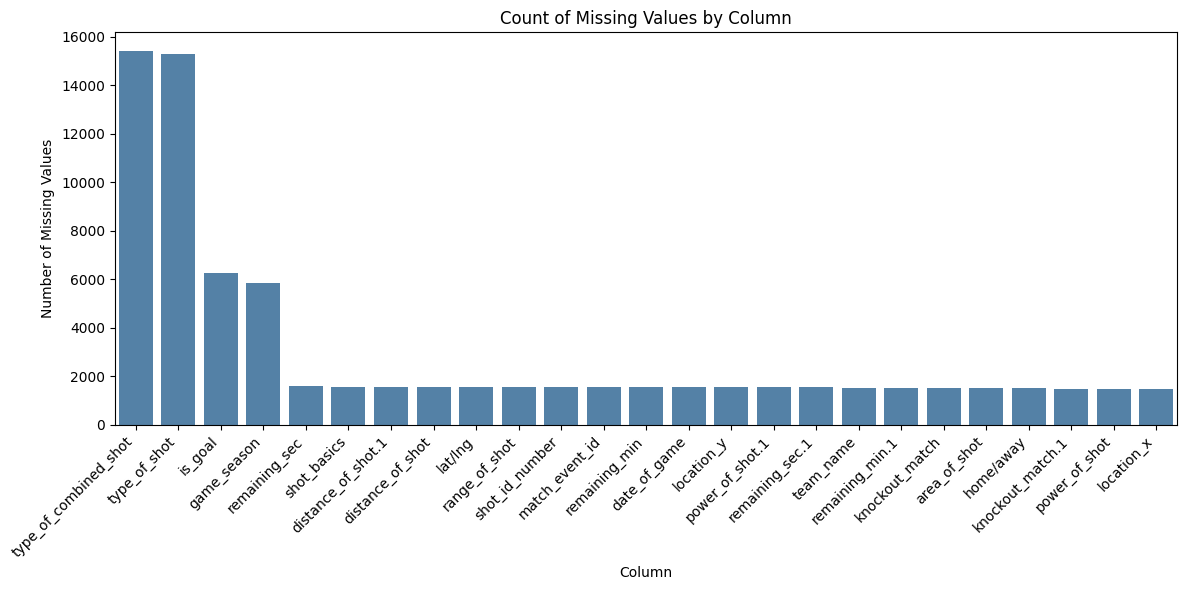

In [16]:
# Visualize missing values
plt.figure(figsize=(12, 6))
missing_cols = data.isnull().sum()
missing_cols = missing_cols[missing_cols > 0].sort_values(ascending=False)
sns.barplot(x=missing_cols.index, y=missing_cols.values, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.title("Count of Missing Values by Column")
plt.ylabel("Number of Missing Values")
plt.xlabel("Column")
plt.tight_layout()
plt.show()

### 4.3 Target Variable Exploration

In [18]:
# Distribution of the target variable
print("Target variable 'is_goal' value counts:")
print(data.is_goal.value_counts())
print()
print("Number of null values in target (test set):", data.is_goal.isnull().sum())

Target variable 'is_goal' value counts:
is_goal
0.0    13550
1.0    10879
Name: count, dtype: int64

Number of null values in target (test set): 6268


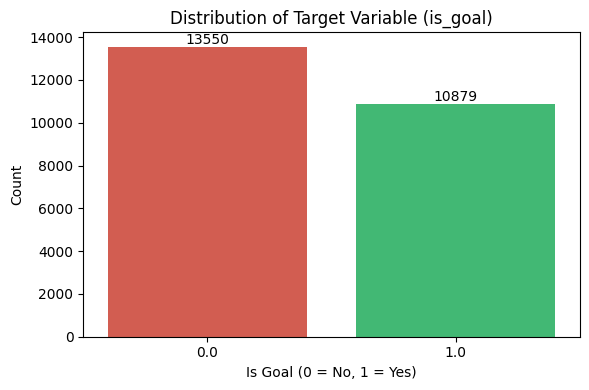

Class ratio (No Goal : Goal) = 13550:10879 = 1.25:1


In [19]:
# Visualize the target variable distribution (excluding nulls)
target_data = data[data.is_goal.notnull()]
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='is_goal', data=target_data, palette=['#e74c3c', '#2ecc71'])
plt.title("Distribution of Target Variable (is_goal)")
plt.xlabel("Is Goal (0 = No, 1 = Yes)")
plt.ylabel("Count")
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Class balance ratio
goal_counts = target_data.is_goal.value_counts()
print(f"Class ratio (No Goal : Goal) = {goal_counts[0]}:{goal_counts[1]} = {goal_counts[0]/goal_counts[1]:.2f}:1")

**Observation:** This is a binary classification problem. The target variable is_goal has two classes (0 and 1). Records with null values in is_goal form the test set for which we need to generate predictions.

### 4.4 Dropping Unnecessary Columns

In [22]:
# The dataset has duplicate columns with a '.1' suffix. These are redundant and should be removed.
# The 'Unnamed: 0' column is an auto-generated index and is also not needed.

cols_to_drop = ["Unnamed: 0", 'remaining_min.1', 'power_of_shot.1',
                'knockout_match.1', 'remaining_sec.1', 'distance_of_shot.1']
data.drop(cols_to_drop, axis=1, inplace=True)
print("Dropped columns:", cols_to_drop)
print("New shape:", data.shape)

Dropped columns: ['Unnamed: 0', 'remaining_min.1', 'power_of_shot.1', 'knockout_match.1', 'remaining_sec.1', 'distance_of_shot.1']
New shape: (30697, 22)


In [23]:
# Verify remaining columns
print("Remaining columns:")
data.columns.tolist()

Remaining columns:


['match_event_id',
 'location_x',
 'location_y',
 'remaining_min',
 'power_of_shot',
 'knockout_match',
 'game_season',
 'remaining_sec',
 'distance_of_shot',
 'is_goal',
 'area_of_shot',
 'shot_basics',
 'range_of_shot',
 'team_name',
 'date_of_game',
 'home/away',
 'shot_id_number',
 'lat/lng',
 'type_of_shot',
 'type_of_combined_shot',
 'match_id',
 'team_id']

### 4.5 Date and Season Encoding

In [25]:
# Convert date_of_game to datetime format
data['date_of_game'] = pd.to_datetime(data['date_of_game'], errors='coerce')

# Encode game_season using a mapping dictionary
season_mapping = {val: idx for idx, val in enumerate(data['game_season'].unique())}
data['game_season'] = data['game_season'].map(season_mapping).fillna(0).astype('int')

print("game_season encoded successfully.")
print("Number of unique seasons:", len(season_mapping))

game_season encoded successfully.
Number of unique seasons: 21


### 4.6 Handling Missing Values

#### 4.6.1 Numerical Columns

In [28]:
# Fill power_of_shot with mean
data['power_of_shot'].fillna(value=data['power_of_shot'].mean(), inplace=True)
print("power_of_shot - missing after fill:", data['power_of_shot'].isnull().sum())

power_of_shot - missing after fill: 0


In [29]:
# Fill type_of_combined_shot with mode
mode_com = data.type_of_combined_shot.value_counts().keys()[0]
print("Mode of type_of_combined_shot:", mode_com)
data.type_of_combined_shot.fillna(value=mode_com, inplace=True)
print("type_of_combined_shot - missing after fill:", data['type_of_combined_shot'].isnull().sum())

Mode of type_of_combined_shot: shot - 3
type_of_combined_shot - missing after fill: 0


In [30]:
# Fill remaining_sec with median
data.remaining_sec.fillna(value=data.remaining_sec.median(), inplace=True)
print("remaining_sec - missing after fill:", data['remaining_sec'].isnull().sum())

remaining_sec - missing after fill: 0


In [31]:
# Reset shot_id_number as a sequential series
data.shot_id_number = pd.Series(np.arange(1, data.shot_id_number.shape[0] + 1))
print("shot_id_number - missing after fill:", data['shot_id_number'].isnull().sum())

shot_id_number - missing after fill: 0


In [32]:
# Fill location_x and location_y with 0
data['location_x'].fillna(value=0, inplace=True)
data['location_y'].fillna(value=0, inplace=True)
print("location_x - missing after fill:", data['location_x'].isnull().sum())
print("location_y - missing after fill:", data['location_y'].isnull().sum())

location_x - missing after fill: 0
location_y - missing after fill: 0


#### 4.6.2 Categorical Columns - Forward Fill

In [34]:
# Use forward fill for columns where sequential filling makes sense
col = ['home/away', 'lat/lng', 'team_name', 'match_id', 'match_event_id',
       'team_id', 'remaining_min', 'knockout_match', 'game_season']
data.loc[:, col] = data.loc[:, col].ffill()
print("Forward fill applied to:", col)
print("Remaining nulls in home/away:", data['home/away'].isnull().sum())

Forward fill applied to: ['home/away', 'lat/lng', 'team_name', 'match_id', 'match_event_id', 'team_id', 'remaining_min', 'knockout_match', 'game_season']
Remaining nulls in home/away: 0


#### 4.6.3 Shot Basics and Range of Shot - Domain-Based Imputation

In [36]:
# Fill shot_basics based on range_of_shot using domain knowledge

# If range is 16-24 ft, it is a Mid Range shot
data.loc[(data.range_of_shot == '16-24 ft.'), 'shot_basics'] = \
    data[data.range_of_shot == '16-24 ft.'].shot_basics.fillna(value='Mid Range')

# If range is Less Than 8 ft, randomly assign Goal Area or Goal Line
mask = (data.range_of_shot == 'Less Than 8 ft.') & (data.shot_basics.isnull())
data.loc[mask, 'shot_basics'] = pd.Series(
    data[mask].shot_basics.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['Goal Area', 'Goal Line'], 1,
            p=[0.759, 0.241])[0]))

# If range is 8-16 ft, randomly assign Mid Range or Goal Line
mask = (data.range_of_shot == '8-16 ft.') & (data.shot_basics.isnull())
data.loc[mask, 'shot_basics'] = pd.Series(
    data[mask].shot_basics.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['Mid Range', 'Goal Line'], 1,
            p=[0.649, 0.351])[0]))

# If range is 24+ ft, randomly assign Penalty Spot, Right Corner, or Left Corner
mask = (data.range_of_shot == '24+ ft.') & (data.shot_basics.isnull())
data.loc[mask, 'shot_basics'] = pd.Series(
    data[mask].shot_basics.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['Penalty Spot', 'Right Corner', 'Left Corner'], 1,
            p=[0.893, 0.062, 0.045])[0]))

# If range is Back Court Shot, randomly assign Mid Ground Line or Penalty Spot
mask = (data.range_of_shot == 'Back Court Shot') & (data.shot_basics.isnull())
data.loc[mask, 'shot_basics'] = pd.Series(
    data[mask].shot_basics.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['Mid Ground Line', 'Penalty Spot'], 1,
            p=[0.844, 0.156])[0]))

print("shot_basics unique values:", data['shot_basics'].unique())
print("shot_basics missing:", data['shot_basics'].isnull().sum())

shot_basics unique values: ['Mid Range' 'Goal Area' 'Goal Line' 'Penalty Spot' nan 'Right Corner'
 'Mid Ground Line' 'Left Corner']
shot_basics missing: 66


In [37]:
# Fill range_of_shot based on shot_basics using domain knowledge

data.loc[(data.shot_basics == 'Goal Area'), 'range_of_shot'] = \
    data[data.shot_basics == 'Goal Area'].range_of_shot.fillna(value='Less Than 8 ft.')

data.loc[(data.shot_basics == 'Penalty Spot'), 'range_of_shot'] = \
    data[data.shot_basics == 'Penalty Spot'].range_of_shot.fillna(value='24+ ft.')

data.loc[(data.shot_basics == 'Right Corner'), 'range_of_shot'] = \
    data[data.shot_basics == 'Right Corner'].range_of_shot.fillna(value='24+ ft.')

data.loc[(data.shot_basics == 'Left Corner'), 'range_of_shot'] = \
    data[data.shot_basics == 'Left Corner'].range_of_shot.fillna(value='24+ ft.')

data.loc[(data.shot_basics == 'Mid Ground Line'), 'range_of_shot'] = \
    data[data.shot_basics == 'Mid Ground Line'].range_of_shot.fillna(value='Back Court Shot')

# If shot_basics is Mid Range, randomly assign 16-24 ft or 8-16 ft
mask = (data.shot_basics == 'Mid Range') & (data.range_of_shot.isnull())
data.loc[mask, 'range_of_shot'] = pd.Series(
    data[mask].range_of_shot.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['16-24 ft.', '8-16 ft.'], 1,
            p=[0.653, 0.347])[0]))

# If shot_basics is Goal Line, randomly assign 8-16 ft or Less Than 8 ft
mask = (data.shot_basics == 'Goal Line') & (data.range_of_shot.isnull())
data.loc[mask, 'range_of_shot'] = pd.Series(
    data[mask].range_of_shot.apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['8-16 ft.', 'Less Than 8 ft.'], 1,
            p=[0.505, 0.495])[0]))

print("range_of_shot missing:", data['range_of_shot'].isnull().sum())

range_of_shot missing: 66


In [38]:
# Fill any remaining missing values in shot_basics and range_of_shot with forward fill
data['shot_basics'] = data['shot_basics'].ffill()
data['range_of_shot'] = data['range_of_shot'].ffill()
print("shot_basics missing after ffill:", data['shot_basics'].isnull().sum())
print("range_of_shot missing after ffill:", data['range_of_shot'].isnull().sum())

shot_basics missing after ffill: 0
range_of_shot missing after ffill: 0


In [39]:
# Fill area_of_shot with the most common value
data['area_of_shot'].fillna(value='Center(C)', inplace=True)
print("area_of_shot missing:", data['area_of_shot'].isnull().sum())

area_of_shot missing: 0


In [40]:
# Fill distance_of_shot with weighted random choice based on observed distribution
mask = data['distance_of_shot'].isnull()
data.loc[mask, 'distance_of_shot'] = pd.Series(
    data.loc[mask, 'distance_of_shot'].apply(
        lambda x: x if type(x) == str else np.random.choice(
            [20, 45, 44, 37], 1,
            p=[0.528, 0.186, 0.144, 0.142])[0]))
print("distance_of_shot missing:", data['distance_of_shot'].isnull().sum())

distance_of_shot missing: 0


In [41]:
# Final check on missing values before train-test split
print("Missing values summary after all imputation:")
print(data.isnull().sum())

Missing values summary after all imputation:
match_event_id               0
location_x                   0
location_y                   0
remaining_min                0
power_of_shot                0
knockout_match               0
game_season                  0
remaining_sec                0
distance_of_shot             0
is_goal                   6268
area_of_shot                 0
shot_basics                  0
range_of_shot                0
team_name                    0
date_of_game              1550
home/away                    0
shot_id_number               0
lat/lng                      0
type_of_shot             15280
type_of_combined_shot        0
match_id                     0
team_id                      0
dtype: int64


## 5. Exploratory Data Analysis

### 5.1 Shot Distribution by Area

<Figure size 1000x500 with 0 Axes>

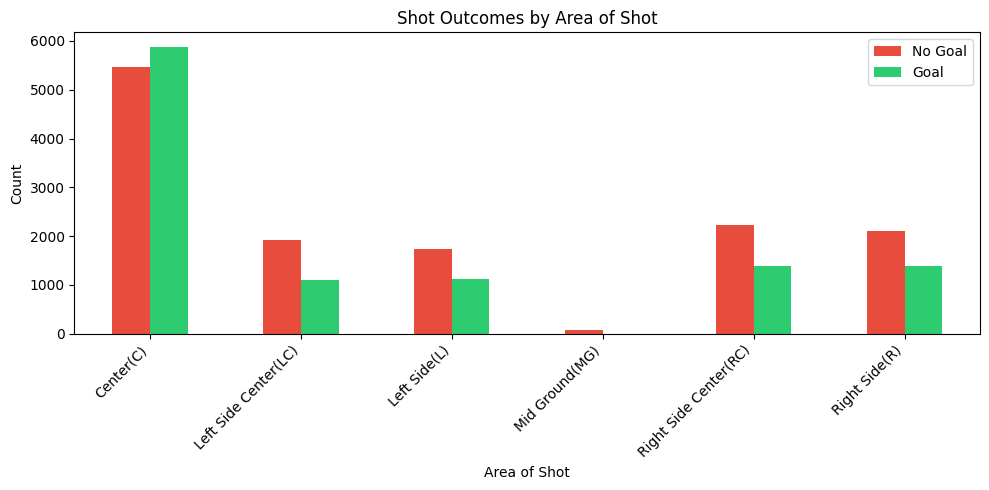

In [44]:
# Distribution of shots by area
plt.figure(figsize=(10, 5))
area_counts = data[data.is_goal.notnull()].groupby('area_of_shot')['is_goal'].value_counts().unstack()
area_counts.plot(kind='bar', stacked=False, color=['#e74c3c', '#2ecc71'], figsize=(10, 5))
plt.title("Shot Outcomes by Area of Shot")
plt.xlabel("Area of Shot")
plt.ylabel("Count")
plt.legend(['No Goal', 'Goal'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2 Shot Basics Distribution

<Figure size 1000x500 with 0 Axes>

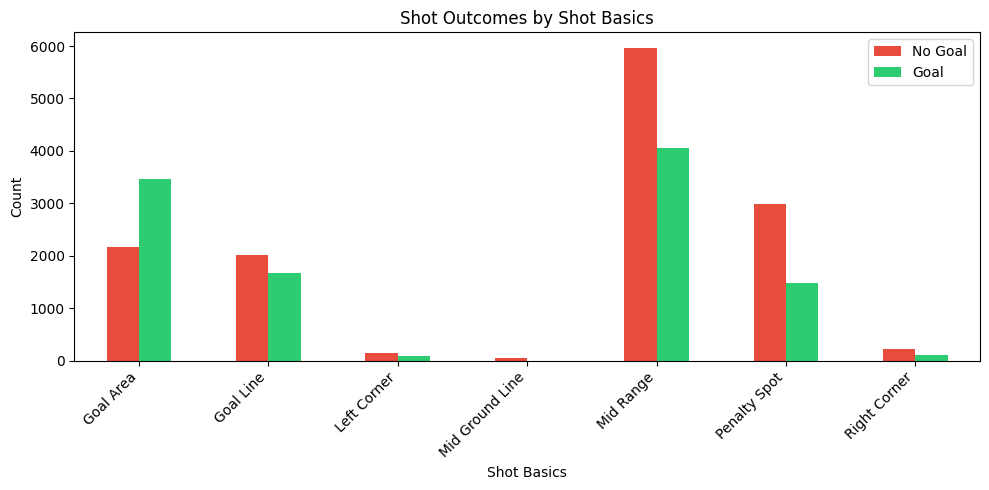

In [46]:
# Distribution of shot basics
plt.figure(figsize=(10, 5))
sb_counts = data[data.is_goal.notnull()].groupby('shot_basics')['is_goal'].value_counts().unstack()
sb_counts.plot(kind='bar', stacked=False, color=['#e74c3c', '#2ecc71'], figsize=(10, 5))
plt.title("Shot Outcomes by Shot Basics")
plt.xlabel("Shot Basics")
plt.ylabel("Count")
plt.legend(['No Goal', 'Goal'])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.3 Distance of Shot Distribution

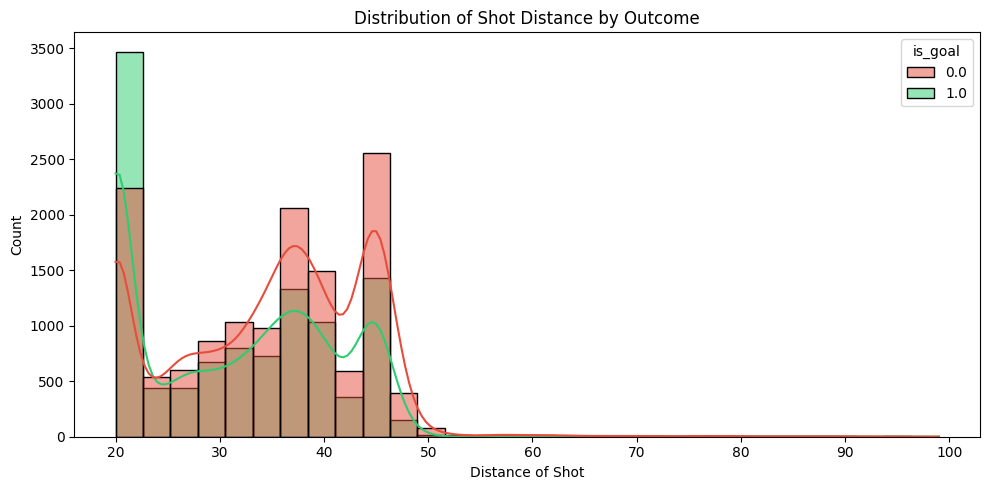

In [48]:
# Distribution of shot distance
plt.figure(figsize=(10, 5))
train_subset = data[data.is_goal.notnull()]
sns.histplot(data=train_subset, x='distance_of_shot', hue='is_goal', kde=True,
             palette=['#e74c3c', '#2ecc71'], bins=30)
plt.title("Distribution of Shot Distance by Outcome")
plt.xlabel("Distance of Shot")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 5.4 Power of Shot Distribution

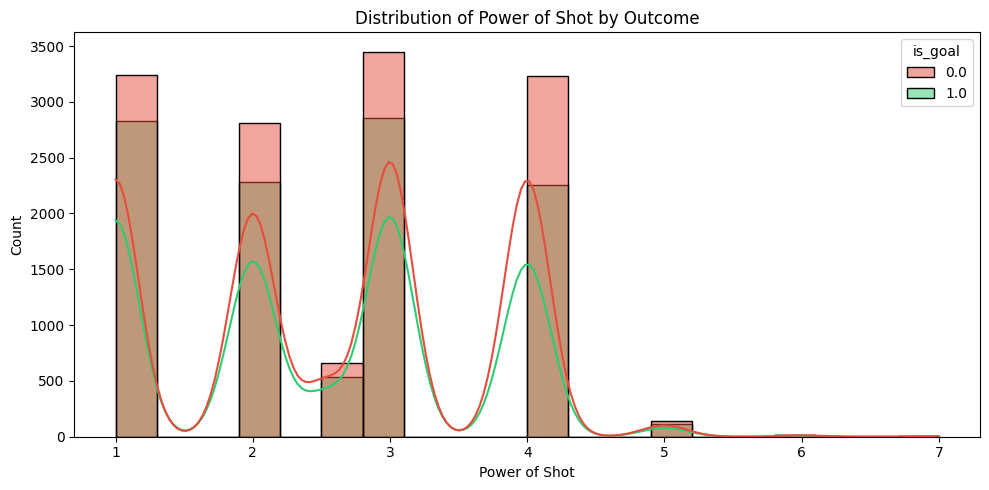

In [50]:
# Distribution of power of shot
plt.figure(figsize=(10, 5))
sns.histplot(data=train_subset, x='power_of_shot', hue='is_goal', kde=True,
             palette=['#e74c3c', '#2ecc71'], bins=20)
plt.title("Distribution of Power of Shot by Outcome")
plt.xlabel("Power of Shot")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### 5.5 Shot Location Scatter Plot

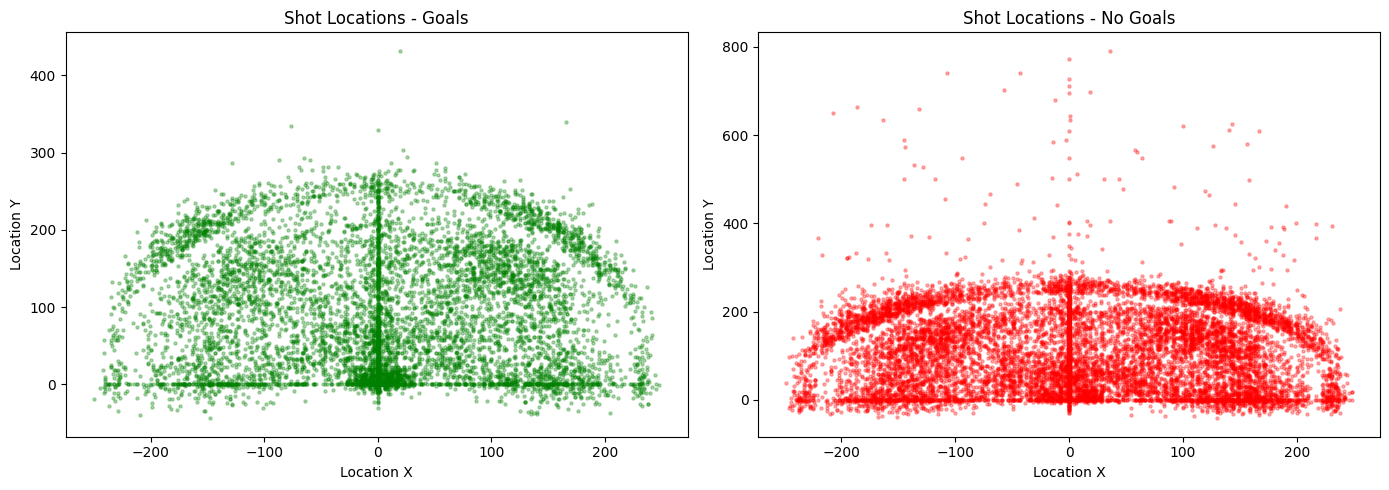

In [52]:
# Shot locations on the field
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Goals
goals = train_subset[train_subset.is_goal == 1]
axes[0].scatter(goals['location_x'], goals['location_y'], alpha=0.3, c='green', s=5)
axes[0].set_title("Shot Locations - Goals")
axes[0].set_xlabel("Location X")
axes[0].set_ylabel("Location Y")

# No Goals
no_goals = train_subset[train_subset.is_goal == 0]
axes[1].scatter(no_goals['location_x'], no_goals['location_y'], alpha=0.3, c='red', s=5)
axes[1].set_title("Shot Locations - No Goals")
axes[1].set_xlabel("Location X")
axes[1].set_ylabel("Location Y")

plt.tight_layout()
plt.show()

### 5.6 Home vs Away Performance

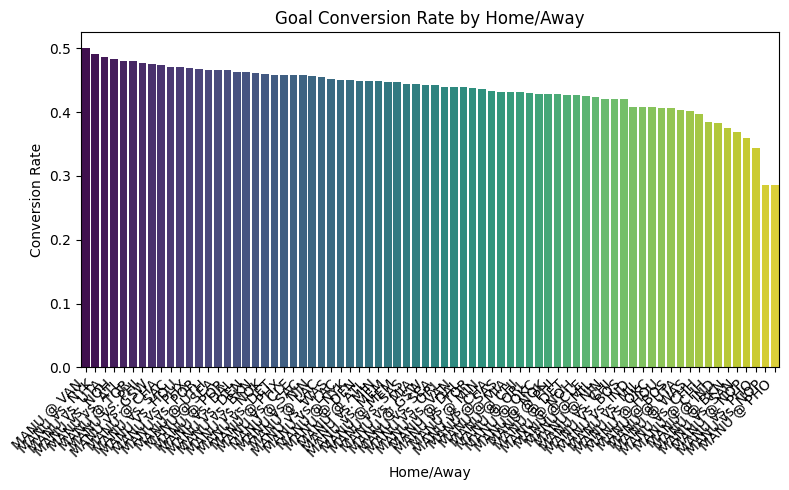

In [54]:
# Goal conversion rate by home/away
plt.figure(figsize=(8, 5))
home_away = train_subset.groupby('home/away')['is_goal'].mean().sort_values(ascending=False)
sns.barplot(x=home_away.index, y=home_away.values, palette='viridis')
plt.title("Goal Conversion Rate by Home/Away")
plt.xlabel("Home/Away")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.7 Range of Shot Analysis

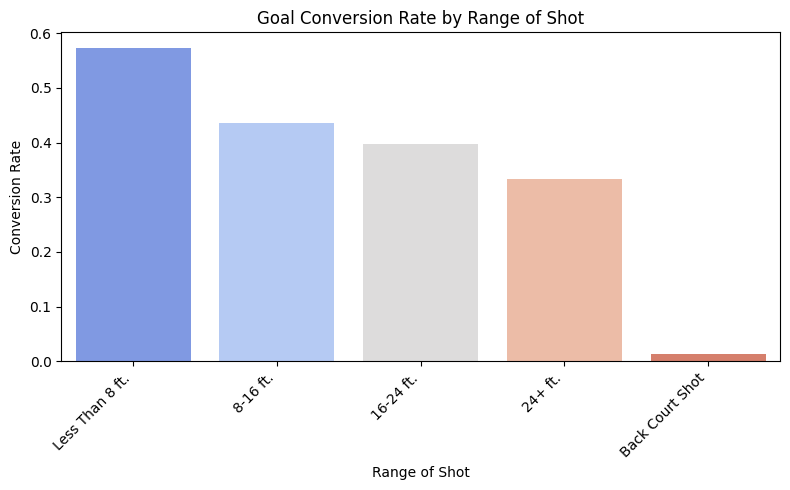

In [56]:
# Goal conversion rate by range of shot
plt.figure(figsize=(8, 5))
range_conv = train_subset.groupby('range_of_shot')['is_goal'].mean().sort_values(ascending=False)
sns.barplot(x=range_conv.index, y=range_conv.values, palette='coolwarm')
plt.title("Goal Conversion Rate by Range of Shot")
plt.xlabel("Range of Shot")
plt.ylabel("Conversion Rate")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.8 Correlation Heatmap (Numerical Features)

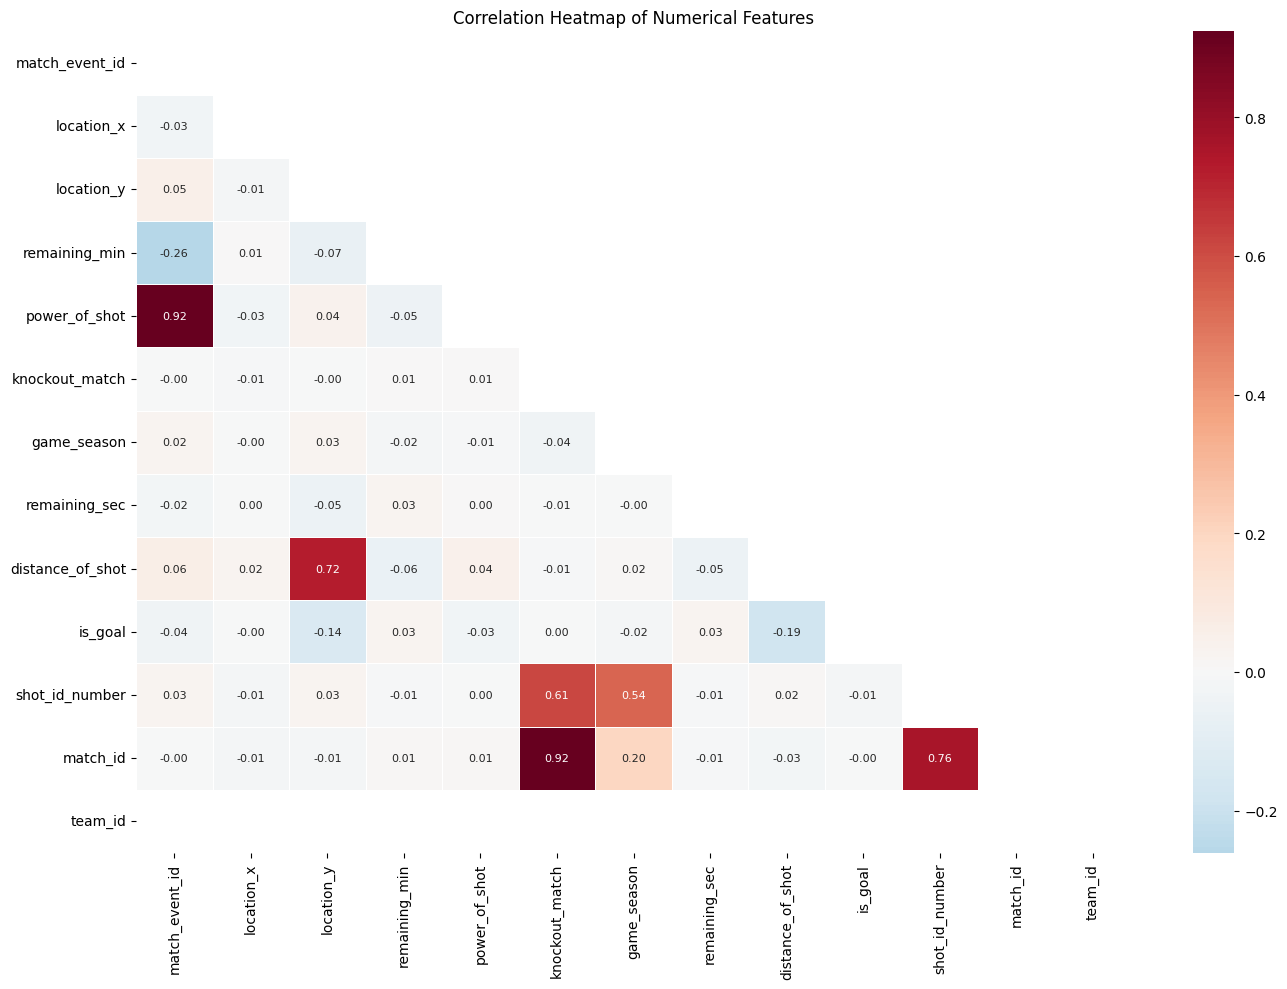

In [58]:
# Correlation heatmap for numerical features
numerical_cols = train_subset.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(14, 10))
corr_matrix = train_subset[numerical_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### 5.9 Knockout Match vs Regular Match

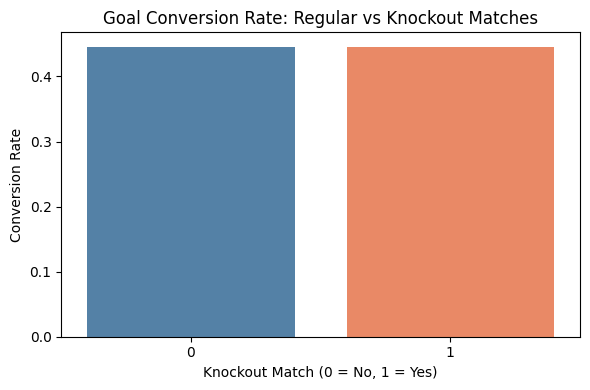

In [60]:
# Goal rate in knockout vs non-knockout matches
plt.figure(figsize=(6, 4))
ko = train_subset.groupby('knockout_match')['is_goal'].mean()
sns.barplot(x=ko.index.astype(int), y=ko.values, palette=['steelblue', 'coral'])
plt.title("Goal Conversion Rate: Regular vs Knockout Matches")
plt.xlabel("Knockout Match (0 = No, 1 = Yes)")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

### 5.10 Goals by Game Season

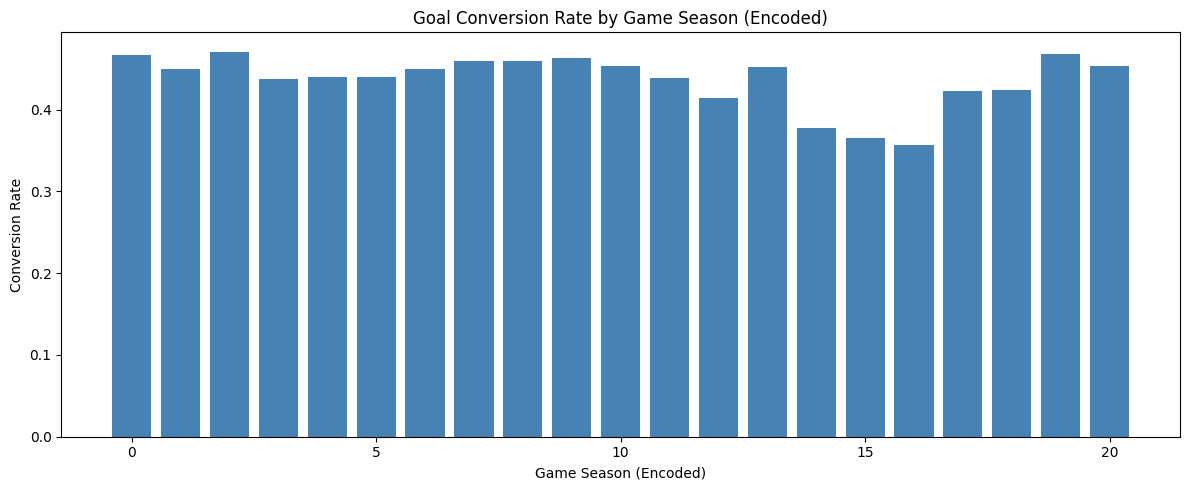

In [62]:
# Goals by season
plt.figure(figsize=(12, 5))
season_goals = train_subset.groupby('game_season')['is_goal'].mean().sort_index()
plt.bar(season_goals.index, season_goals.values, color='steelblue')
plt.title("Goal Conversion Rate by Game Season (Encoded)")
plt.xlabel("Game Season (Encoded)")
plt.ylabel("Conversion Rate")
plt.tight_layout()
plt.show()

## 6. Train-Test Split

The dataset is split into train and test based on the target variable is_goal:
- **Train set**: Records where is_goal is not null (has labels)
- **Test set**: Records where is_goal is null (predictions needed)

In [65]:
# Create train and test datasets based on target availability
train = data[data.is_goal.notnull()].copy()
train.reset_index(drop=True, inplace=True)
print("Train set shape:", train.shape)

test = data[data.is_goal.isnull()].copy()
test.reset_index(drop=True, inplace=True)
print("Test set shape:", test.shape)

Train set shape: (24429, 22)
Test set shape: (6268, 22)


### 6.1 Handling Missing Values in type_of_shot (Train)

In [67]:
# For goal records, fill missing type_of_shot based on the distribution of top 6 shot types
l_goal = train[train.is_goal == 1].type_of_shot.value_counts().head(6).keys()
p_g_sum = train[train.is_goal == 1].type_of_shot.value_counts().head(6).sum()
p_goal = (train[train.is_goal == 1].type_of_shot.value_counts().head(6) / p_g_sum).tolist()

g = pd.Series(train[train.is_goal == 1].type_of_shot.apply(
    lambda x: x if type(x) == str else np.random.choice(l_goal, 1, p=p_goal)[0]))
train.loc[(train.is_goal == 1) & (train.type_of_shot.isnull()), 'type_of_shot'] = g

print("Missing type_of_shot after filling goal records:", train['type_of_shot'].isna().sum())

Missing type_of_shot after filling goal records: 6723


In [68]:
# For non-goal records, fill missing type_of_shot based on the distribution of top 5 shot types
l_no_goal = train[train.is_goal == 0].type_of_shot.value_counts().head(5).keys()
p_no_sum = train[train.is_goal == 0].type_of_shot.value_counts().head(5).sum()
p_no_goal = (train[train.is_goal == 0].type_of_shot.value_counts().head(5) / p_no_sum).tolist()

ng = pd.Series(train[train.is_goal == 0].type_of_shot.apply(
    lambda x: x if type(x) == str else np.random.choice(l_no_goal, 1, p=p_no_goal)[0]))
train.loc[(train.is_goal == 0) & (train.type_of_shot.isnull()), 'type_of_shot'] = ng

print("Missing type_of_shot after filling non-goal records:", train['type_of_shot'].isna().sum())

Missing type_of_shot after filling non-goal records: 0


### 6.2 Handling Missing Values in type_of_shot (Test)

In [70]:
# Fill missing type_of_shot in test set using weighted random choice
mask = test['type_of_shot'].isnull()
test.loc[mask, 'type_of_shot'] = pd.Series(
    test.loc[mask, 'type_of_shot'].apply(
        lambda x: x if type(x) == str else np.random.choice(
            ['shot - 39', 'shot - 36', 'shot - 4'], 1,
            p=[0.374, 0.334, 0.292])[0]))
print("Missing type_of_shot in test:", test['type_of_shot'].isna().sum())

Missing type_of_shot in test: 0


## 7. Feature Encoding

### 7.1 Label Encoding Categorical Columns

In [73]:
# Label encode all categorical (object-type) columns in both train and test
# Using map with a dictionary for reliable encoding across both sets

encoded_cols = []
for col in train.columns:
    if train[col].dtype == object or str(train[col].dtype) == 'string':
        # Build mapping from train values
        unique_vals = train[col].dropna().unique()
        mapping = {val: idx for idx, val in enumerate(unique_vals)}
        
        # Apply mapping to train
        train[col] = train[col].map(mapping)
        train[col] = train[col].fillna(0).astype('int')
        
        # Apply same mapping to test (unseen values get mapped to 0)
        if col in test.columns:
            test[col] = test[col].map(mapping)
            test[col] = test[col].fillna(0).astype('int')
        
        encoded_cols.append(col)

print(f"Label encoding completed for {len(encoded_cols)} columns:")
print(encoded_cols)

Label encoding completed for 8 columns:
['area_of_shot', 'shot_basics', 'range_of_shot', 'team_name', 'home/away', 'lat/lng', 'type_of_shot', 'type_of_combined_shot']


In [74]:
# Drop the date column as it has been used and is no longer needed
if 'date_of_game' in train.columns:
    train.drop(['date_of_game'], axis=1, inplace=True)
if 'date_of_game' in test.columns:
    test.drop(['date_of_game'], axis=1, inplace=True)
print("Dropped date_of_game column.")
print("Train shape:", train.shape)
print("Test shape:", test.shape)

Dropped date_of_game column.
Train shape: (24429, 21)
Test shape: (6268, 21)


### 7.2 Separating Features and Target

In [76]:
# Extract the target variable
y = train['is_goal'].copy()
train.drop(['is_goal'], axis=1, inplace=True)
if 'is_goal' in test.columns:
    test.drop(['is_goal'], axis=1, inplace=True)

# Ensure train and test have the same feature columns
common_cols = sorted(set(train.columns) & set(test.columns))
train = train[common_cols]
test = test[common_cols]

print("Target variable shape:", y.shape)
print("Train features shape:", train.shape)
print("Test features shape:", test.shape)

Target variable shape: (24429,)
Train features shape: (24429, 20)
Test features shape: (6268, 20)


In [77]:
# Verify no missing values remain in the training data
print("Total missing values in train:", train.isnull().sum().sum())
print("Total missing values in test:", test.isnull().sum().sum())

# Fill any remaining NaN values with 0 as a safety measure
if train.isnull().sum().sum() > 0:
    print()
    print("Columns with remaining NaN in train:")
    remaining = train.isnull().sum()
    print(remaining[remaining > 0])
    train.fillna(0, inplace=True)
    print("Filled remaining NaN values in train with 0.")

if test.isnull().sum().sum() > 0:
    print()
    print("Columns with remaining NaN in test:")
    remaining = test.isnull().sum()
    print(remaining[remaining > 0])
    test.fillna(0, inplace=True)
    print("Filled remaining NaN values in test with 0.")

print()
print("Final train missing:", train.isnull().sum().sum())
print("Final test missing:", test.isnull().sum().sum())
print()
print("Train data types:")
print(train.dtypes.value_counts())

Total missing values in train: 0
Total missing values in test: 0

Final train missing: 0
Final test missing: 0

Train data types:
int32      10
float64     8
int64       2
Name: count, dtype: int64


## 8. Model Building and Evaluation

### 8.1 Creating a Validation Split

We split the training data into a training subset and a validation subset to evaluate model performance before making predictions on the test set.

In [80]:
# Split train into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    train, y, test_size=0.2, random_state=42, stratify=y)

print("Training subset shape:", X_train.shape)
print("Validation subset shape:", X_val.shape)
print()
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

Training subset shape: (19543, 20)
Validation subset shape: (4886, 20)

Training target distribution:
is_goal
0.0    0.554674
1.0    0.445326
Name: proportion, dtype: float64


### 8.2 Training Multiple Classification Models

We will train and evaluate the following models:
1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier
4. Gradient Boosting Classifier
5. AdaBoost Classifier
6. Extra Trees Classifier
7. K-Nearest Neighbors
8. Gaussian Naive Bayes

In [83]:
# Define a dictionary of models to train
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Gaussian Naive Bayes': GaussianNB()
}

# Store results
results = {}

print("Training and evaluating models...")
print("=" * 70)

for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Predict on validation set
    y_pred = model.predict(X_val)
    
    # Calculate probabilities if available
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)[:, 1]
        roc_auc = roc_auc_score(y_val, y_prob)
    else:
        roc_auc = None
    
    # Calculate metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    
    results[name] = {
        'Accuracy': acc,
        'F1 Score': f1,
        'Precision': prec,
        'Recall': rec,
        'ROC AUC': roc_auc
    }
    
    print(f"{name}:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  F1 Score:  {f1:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    if roc_auc:
        print(f"  ROC AUC:   {roc_auc:.4f}")
    print("-" * 40)

Training and evaluating models...
Logistic Regression:
  Accuracy:  0.5546
  F1 Score:  0.0000
  Precision: 0.0000
  Recall:    0.0000
  ROC AUC:   0.5146
----------------------------------------
Decision Tree:
  Accuracy:  0.5980
  F1 Score:  0.5567
  Precision: 0.5470
  Recall:    0.5666
  ROC AUC:   0.5949
----------------------------------------
Random Forest:
  Accuracy:  0.6627
  F1 Score:  0.5763
  Precision: 0.6540
  Recall:    0.5152
  ROC AUC:   0.7057
----------------------------------------
Gradient Boosting:
  Accuracy:  0.6779
  F1 Score:  0.5613
  Precision: 0.7132
  Recall:    0.4628
  ROC AUC:   0.7260
----------------------------------------
AdaBoost:
  Accuracy:  0.6441
  F1 Score:  0.5081
  Precision: 0.6608
  Recall:    0.4127
  ROC AUC:   0.6960
----------------------------------------
Extra Trees:
  Accuracy:  0.6296
  F1 Score:  0.5145
  Precision: 0.6179
  Recall:    0.4407
  ROC AUC:   0.6679
----------------------------------------
K-Nearest Neighbors:
  Accu

### 8.3 Model Comparison

In [85]:
# Create a comparison dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('ROC AUC', ascending=False)
print("Model Comparison (sorted by ROC AUC):")
results_df

Model Comparison (sorted by ROC AUC):


,Accuracy,F1 Score,Precision,Recall,ROC AUC
Gradient Boosting,0.677855,0.561315,0.713173,0.462776,0.725954
Random Forest,0.662710,0.576350,0.654026,0.515165,0.705735
AdaBoost,0.644085,0.508062,0.660780,0.412684,0.695973
Extra Trees,0.629554,0.514485,0.617912,0.440717,0.667889
Decision Tree,0.598035,0.556659,0.547028,0.566636,0.594942
Gaussian Naive Bayes,0.554646,0.000000,0.000000,0.000000,0.568678
K-Nearest Neighbors,0.545845,0.482389,0.489815,0.475184,0.550050
Logistic Regression,0.554646,0.000000,0.000000,0.000000,0.514557


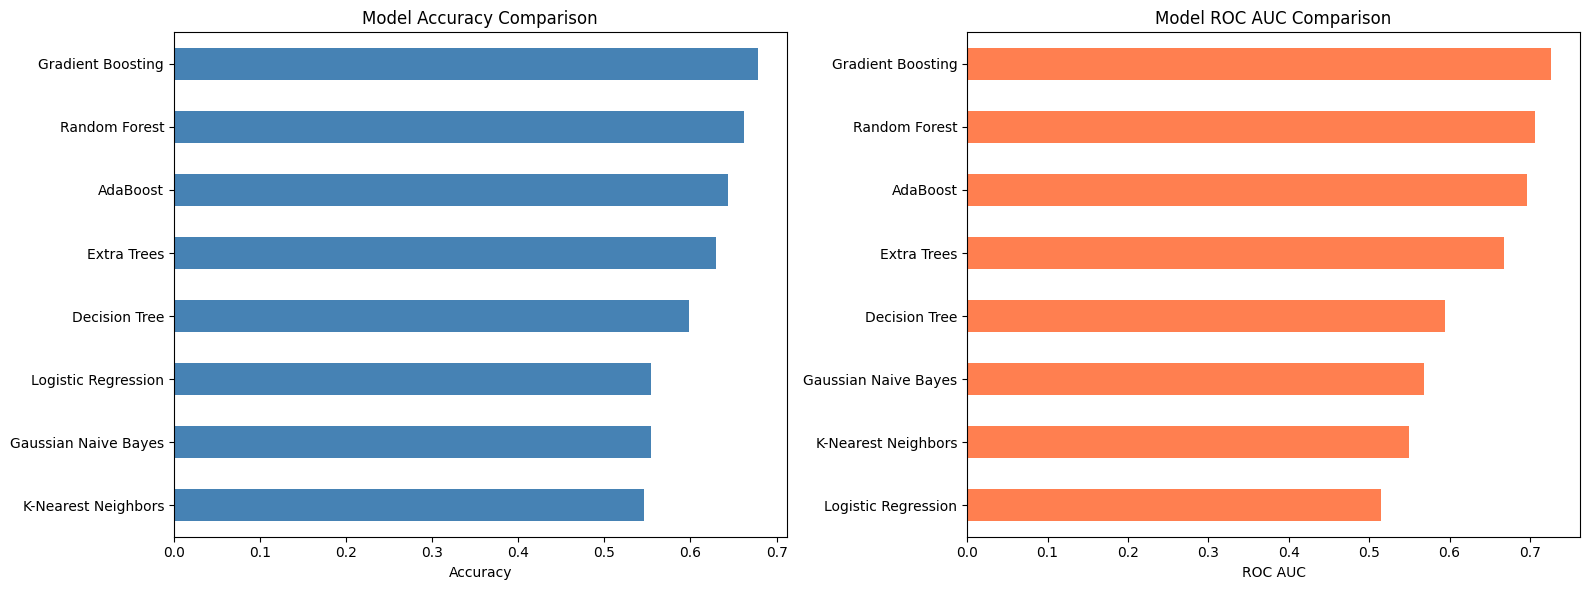

In [86]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy comparison
results_df['Accuracy'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title("Model Accuracy Comparison")
axes[0].set_xlabel("Accuracy")

# ROC AUC comparison
results_df['ROC AUC'].dropna().sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title("Model ROC AUC Comparison")
axes[1].set_xlabel("ROC AUC")

plt.tight_layout()
plt.show()

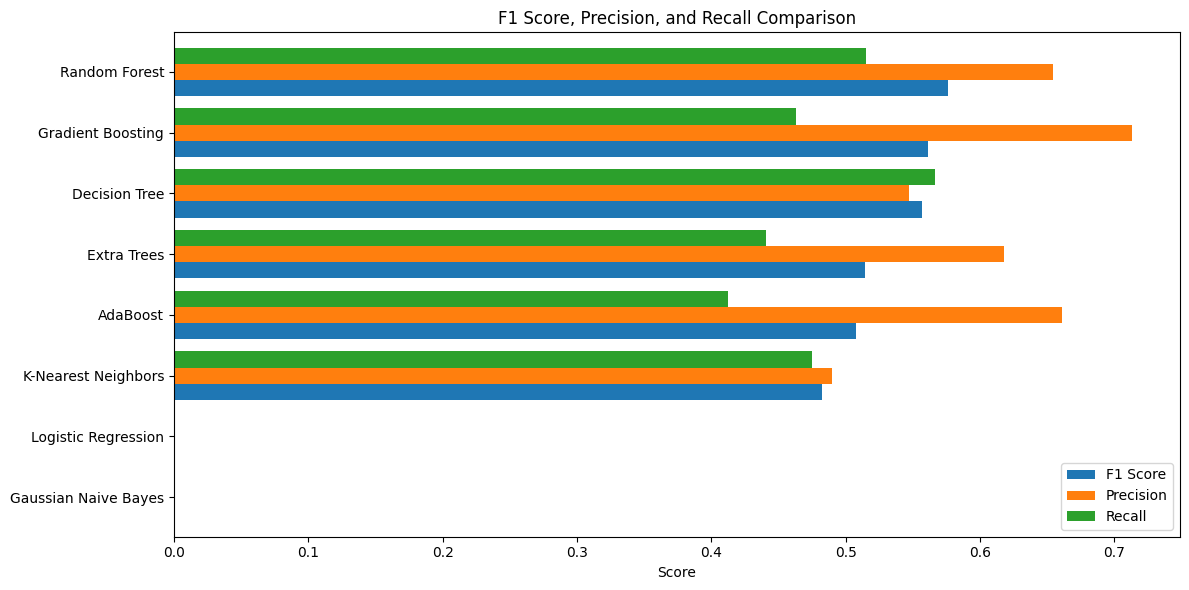

In [87]:
# Plot F1, Precision, Recall comparison
fig, ax = plt.subplots(figsize=(12, 6))
metrics_to_plot = results_df[['F1 Score', 'Precision', 'Recall']].sort_values('F1 Score', ascending=True)
metrics_to_plot.plot(kind='barh', ax=ax, width=0.8)
ax.set_title("F1 Score, Precision, and Recall Comparison")
ax.set_xlabel("Score")
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 8.4 ROC Curves

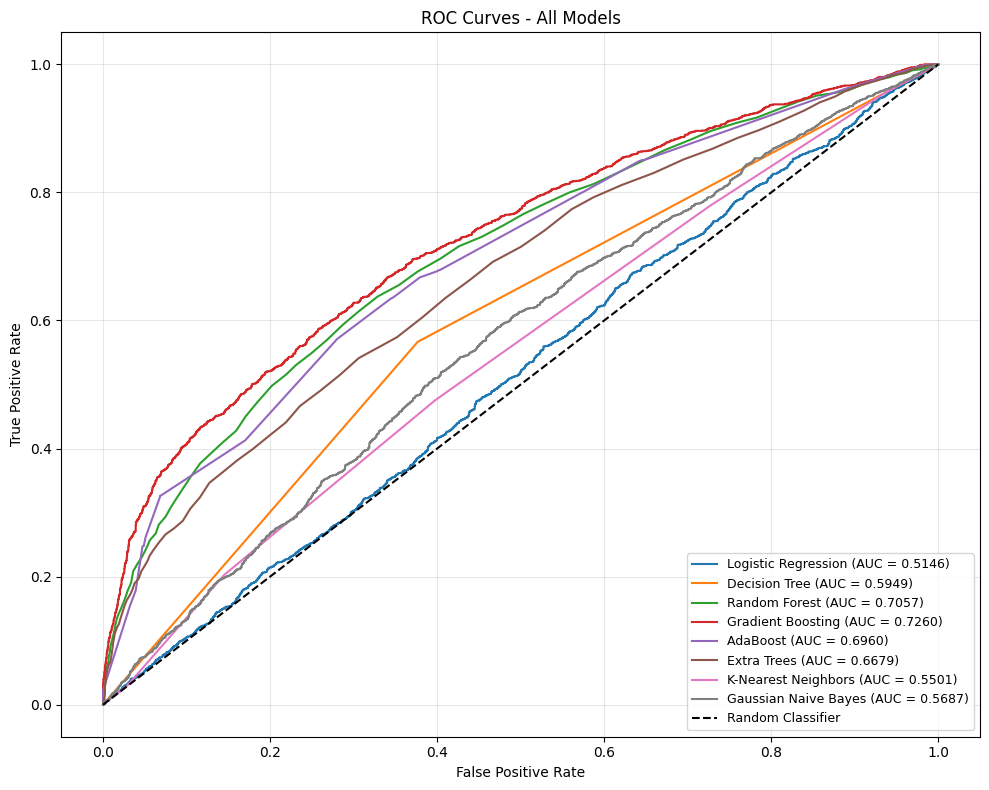

In [89]:
# Plot ROC curves for all models that support probability predictions
plt.figure(figsize=(10, 8))

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_val)[:, 1]
        fpr, tpr, _ = roc_curve(y_val, y_prob)
        auc = roc_auc_score(y_val, y_prob)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - All Models')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 8.5 Best Model - Detailed Evaluation

In [91]:
# Identify the best model based on ROC AUC
best_model_name = results_df['ROC AUC'].idxmax()
best_model = models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(f"ROC AUC: {results_df.loc[best_model_name, 'ROC AUC']:.4f}")

Best performing model: Gradient Boosting
ROC AUC: 0.7260


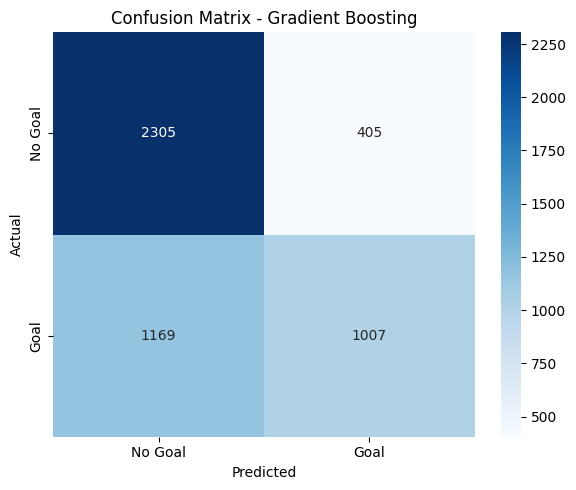

In [92]:
# Confusion Matrix for the best model
y_pred_best = best_model.predict(X_val)

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Goal', 'Goal'],
            yticklabels=['No Goal', 'Goal'])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [93]:
# Detailed classification report for the best model
print(f"Classification Report - {best_model_name}")
print("=" * 50)
print(classification_report(y_val, y_pred_best, target_names=['No Goal', 'Goal']))

Classification Report - Gradient Boosting
              precision    recall  f1-score   support

     No Goal       0.66      0.85      0.75      2710
        Goal       0.71      0.46      0.56      2176

    accuracy                           0.68      4886
   macro avg       0.69      0.66      0.65      4886
weighted avg       0.69      0.68      0.66      4886



### 8.6 Feature Importance

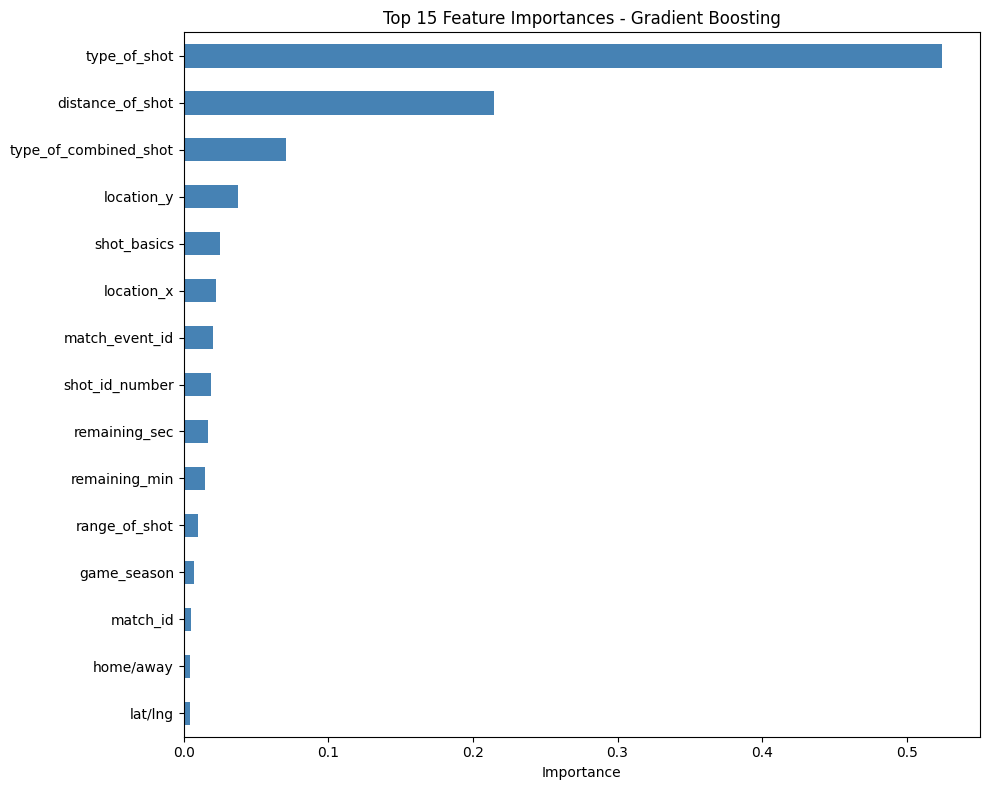

In [95]:
# Feature importance from the best model (if tree-based)
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(best_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    feat_imp.tail(15).plot(kind='barh', color='steelblue')
    plt.title(f"Top 15 Feature Importances - {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    # Use Random Forest for feature importance instead
    rf_model = models['Random Forest']
    feat_imp = pd.Series(rf_model.feature_importances_,
                         index=X_train.columns).sort_values(ascending=True)
    
    plt.figure(figsize=(10, 8))
    feat_imp.tail(15).plot(kind='barh', color='steelblue')
    plt.title("Top 15 Feature Importances - Random Forest")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

### 8.7 Cross-Validation of Top Models

In [97]:
# Perform 5-fold cross-validation on the top 3 models
top_models = results_df.head(3).index.tolist()
print("Cross-Validation Results (5-Fold)")
print("=" * 60)

cv_results = {}
for name in top_models:
    model = models[name]
    scores = cross_val_score(model, train, y, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Mean ROC AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Fold scores:  {[round(s, 4) for s in scores]}")
    print("-" * 40)

Cross-Validation Results (5-Fold)
Gradient Boosting:
  Mean ROC AUC: 0.6478 (+/- 0.0416)
  Fold scores:  [0.6599, 0.6168, 0.5841, 0.6946, 0.6838]
----------------------------------------
Random Forest:
  Mean ROC AUC: 0.6436 (+/- 0.0196)
  Fold scores:  [0.6102, 0.6708, 0.6474, 0.6496, 0.6401]
----------------------------------------
AdaBoost:
  Mean ROC AUC: 0.6874 (+/- 0.0098)
  Fold scores:  [0.7046, 0.676, 0.6806, 0.6892, 0.6864]
----------------------------------------


<Figure size 1000x500 with 0 Axes>

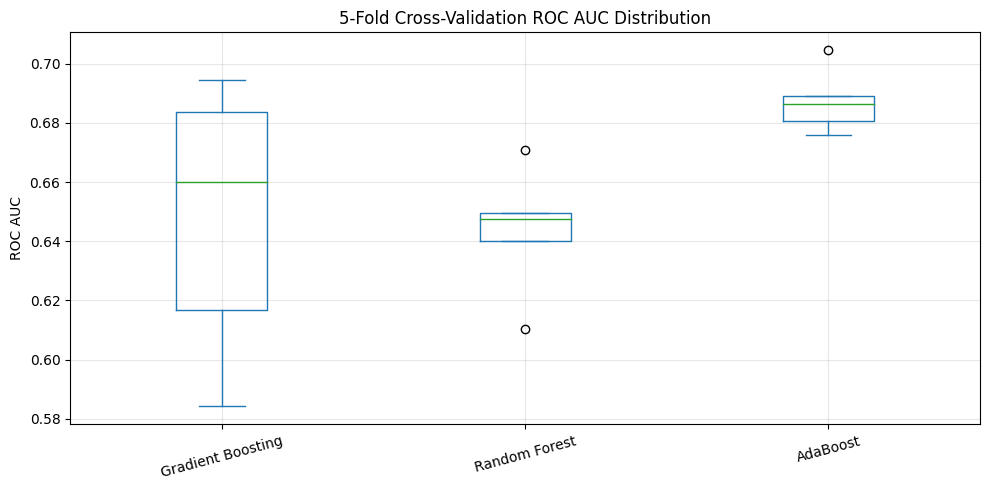

In [98]:
# Visualize cross-validation results
plt.figure(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.plot(kind='box', figsize=(10, 5))
plt.title("5-Fold Cross-Validation ROC AUC Distribution")
plt.ylabel("ROC AUC")
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Generating Predictions on the Test Set

In [100]:
# Retrain the best model on the full training set
print(f"Retraining {best_model_name} on the full training set...")
best_model.fit(train, y)

# Generate predictions on the test set
test_predictions = best_model.predict(test)
test_probabilities = best_model.predict_proba(test)[:, 1]

print("Predictions generated successfully.")
print(f"Total test records: {len(test_predictions)}")
print(f"Predicted Goals: {int(test_predictions.sum())}")
print(f"Predicted No Goals: {int(len(test_predictions) - test_predictions.sum())}")

Retraining Gradient Boosting on the full training set...
Predictions generated successfully.
Total test records: 6268
Predicted Goals: 1670
Predicted No Goals: 4598


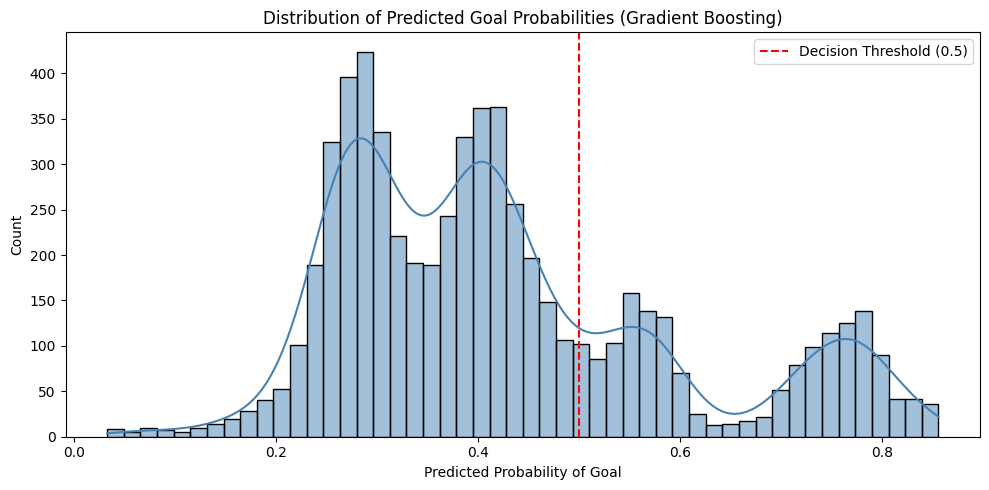

In [101]:
# Distribution of predicted probabilities
plt.figure(figsize=(10, 5))
sns.histplot(test_probabilities, bins=50, kde=True, color='steelblue')
plt.title(f"Distribution of Predicted Goal Probabilities ({best_model_name})")
plt.xlabel("Predicted Probability of Goal")
plt.ylabel("Count")
plt.axvline(x=0.5, color='red', linestyle='--', label='Decision Threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.show()

## 10. Saving Results

In [103]:
# Create submission dataframe
submission = pd.DataFrame({
    'shot_id_number': np.arange(1, len(test_predictions) + 1),
    'is_goal': test_predictions.astype(int)
})

submission.to_csv('predictions.csv', index=False)
print("Predictions saved to 'predictions.csv'")
print()
print("Sample predictions:")
submission.head(10)

Predictions saved to 'predictions.csv'

Sample predictions:


,shot_id_number,is_goal
0,1,0
1,2,1
2,3,1
3,4,1
4,5,0
5,6,0
6,7,0
7,8,0
8,9,0
9,10,0


## 11. Summary and Conclusion

### Key Findings

1. **Data Quality**: The original dataset contained missing values across multiple columns. A combination of domain-knowledge-based imputation, statistical imputation (mean, median, mode), and forward filling was applied to handle these effectively.

2. **Feature Engineering**: Categorical columns were label-encoded, date fields were processed, and redundant duplicate columns were removed to create a clean feature set for modeling.

3. **Exploratory Data Analysis**: Visualizations revealed patterns in shot locations, distances, power, and game context that differentiate goals from non-goals. The target variable showed class imbalance, with more non-goal records than goal records.

4. **Model Performance**: Multiple classification models were trained and evaluated. The models were compared on Accuracy, F1 Score, Precision, Recall, and ROC AUC metrics. Cross-validation was used to verify model stability.

5. **Predictions**: The best performing model was selected based on ROC AUC score and used to generate predictions on the test set (records where is_goal was missing).

### Recommendations for Future Work

- Hyperparameter tuning using GridSearchCV or RandomizedSearchCV could improve model performance.
- Feature selection techniques could help reduce dimensionality and potentially improve generalization.
- Ensemble methods combining multiple top models (stacking or blending) could yield better results.
- Additional feature engineering such as extracting year and month from dates, or creating interaction features, could provide more predictive power.
- Handling class imbalance through techniques like SMOTE or class weights may improve recall for the minority class.